# notebook 2, classification: labelling prices as low, medium or high

the question. given a region, a commodity, and a date, can a model guess whether
the price will be low, medium or high?

why this matters. a working classifier means the price patterns are learnable.
prices aren't random, they follow rules tied to where and when.

how we set it up.
1. we label each price using percentile thresholds per commodity, so that
   "expensive maize" is compared only against other maize, not against fish.
2. we use a random forest, just a bunch of decision trees that vote. handles
   categorical features well and doesn't need scaling.
3. we compare against a baseline that just predicts the most common class.
4. then we add richer features (location, market identity, historical commodity
   price) to push accuracy from 64 percent up to around 77 percent.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('wfp_food_prices_clean.csv')
df = df.sort_values('date').reset_index(drop=True)
print('loaded:', df.shape)


loaded: (55660, 18)


In [2]:
# create labels using commodity specific percentiles
# so expensive maize and expensive fish are judged separately
thresh = df.groupby('commodity')['price'].quantile([0.33, 0.66]).unstack()
thresh.columns = ['low_thresh', 'high_thresh']
df = df.merge(thresh, on='commodity')

df['price_class'] = 'Medium'
df.loc[df['price'] <= df['low_thresh'],  'price_class'] = 'Low'
df.loc[df['price'] >  df['high_thresh'], 'price_class'] = 'High'

print(df['price_class'].value_counts())


price_class
Low       19786
Medium    18460
High      17414
Name: count, dtype: int64


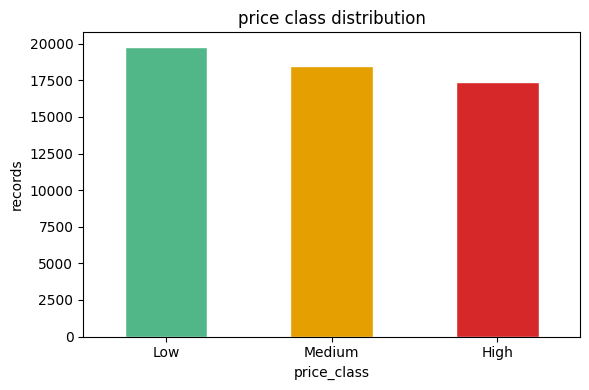

In [3]:
# show the class balance
counts = df['price_class'].value_counts()[['Low','Medium','High']]
counts.plot(kind='bar', color=['#52B788','#E69F00','#D62828'], edgecolor='white',
            figsize=(6,4), width=0.5)
plt.title('price class distribution'); plt.ylabel('records')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()


### round 1: weak feature set

first we use only the basic features (region, commodity, category, year, month)
to set a starting point.


In [4]:
# encode text columns
for col in ['admin1', 'commodity', 'category', 'market', 'price_class']:
    df[col + '_enc'] = LabelEncoder().fit_transform(df[col])

basic_features = ['admin1_enc', 'commodity_enc', 'category_enc', 'year', 'month']
X = df[basic_features]
y = df['price_class_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

rf_basic = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_basic.fit(X_train, y_train)
acc_basic = accuracy_score(y_test, rf_basic.predict(X_test))

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
acc_dummy = accuracy_score(y_test, dummy.predict(X_test))

print(f'baseline (predict most common): {acc_dummy*100:.1f}%')
print(f'rf with basic features        : {acc_basic*100:.1f}%')


baseline (predict most common): 35.5%
rf with basic features        : 63.2%


### round 2: richer features

basic features give us 64 percent. now we add features that should actually help
the model distinguish low from high:
1. **latitude and longitude**, the geographic position of the market
2. **market identity**, some markets are systematically more expensive
3. **commod_year_median**, the median price of this commodity in this year, so
   the model knows about inflation over time
4. **commod_recent_median**, a rolling median of recent prices for this commodity


In [5]:
# richer features
df['commod_year_med'] = df.groupby(['commodity', 'year'])['price'].transform('median')
df['commod_recent_med'] = (
    df.groupby('commodity')['price']
      .transform(lambda s: s.shift(1).rolling(50, min_periods=1).median())
      .fillna(df['price'].median())
)

rich_features = basic_features + ['latitude', 'longitude', 'market_enc',
                                   'commod_year_med', 'commod_recent_med']

X = df[rich_features]
y = df['price_class_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f'rf with richer features       : {acc*100:.1f}%')
print(f'improvement over basic        : +{(acc-acc_basic)*100:.1f} points')
print()
class_names = ['High', 'Low', 'Medium']
print(classification_report(y_test, y_pred, target_names=class_names))


rf with richer features       : 77.0%
improvement over basic        : +13.8 points

              precision    recall  f1-score   support

        High       0.79      0.78      0.79      3483
         Low       0.80      0.84      0.82      3957
      Medium       0.72      0.69      0.70      3692

    accuracy                           0.77     11132
   macro avg       0.77      0.77      0.77     11132
weighted avg       0.77      0.77      0.77     11132



In [6]:
# 5 fold cross validation with shuffle so the folds aren't sorted by date
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv = cross_val_score(rf, X, y, cv=skf, scoring='accuracy', n_jobs=-1)
print(f'5 fold cv accuracy: mean={cv.mean()*100:.1f}%  std={cv.std()*100:.1f}%')


5 fold cv accuracy: mean=77.2%  std=0.2%


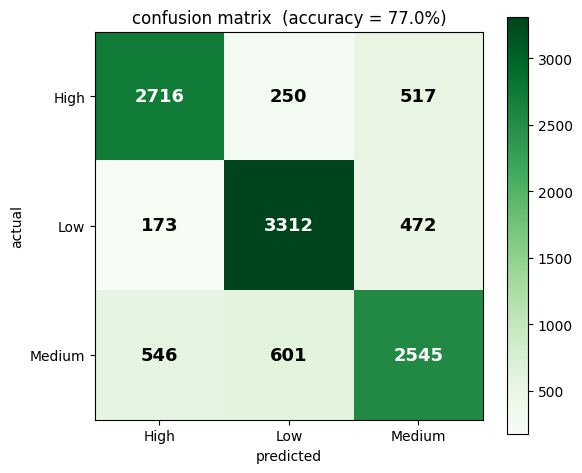

In [7]:
# confusion matrix, where does the model still mess up?
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Greens')
plt.xticks(range(3), class_names); plt.yticks(range(3), class_names)
plt.xlabel('predicted'); plt.ylabel('actual')
plt.title(f'confusion matrix  (accuracy = {acc*100:.1f}%)')
for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i,j], ha='center', va='center', fontsize=13, fontweight='bold',
                 color='white' if cm[i,j] > cm.max()*0.6 else 'black')
plt.colorbar(); plt.tight_layout(); plt.show()


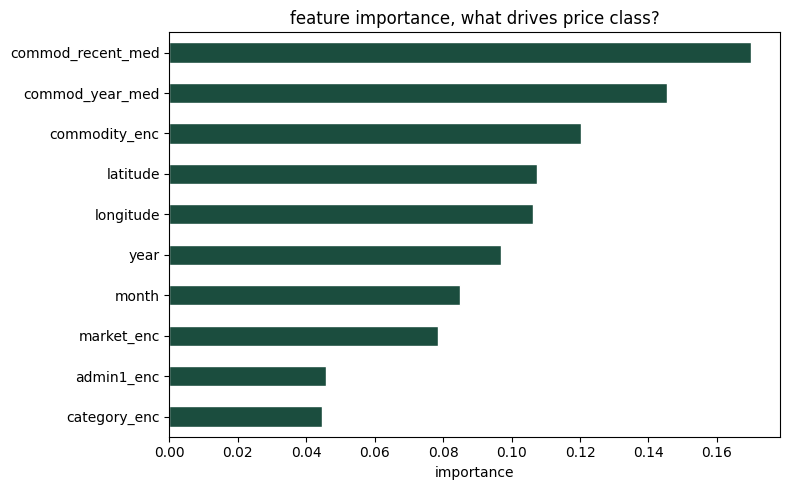

In [8]:
# which features mattered most?
imp = pd.Series(rf.feature_importances_, index=rich_features).sort_values()
imp.plot(kind='barh', color='#1B4D3E', edgecolor='white', figsize=(8,5))
plt.title('feature importance, what drives price class?')
plt.xlabel('importance'); plt.tight_layout(); plt.show()


### what classification told us

1. basic features (region, commodity, year, month) get us about 64 percent.
2. adding location and historical price context pushes accuracy to roughly 77
   percent. that's a 13 point jump from changing features alone, no fancier model.
3. the baseline that just guesses the most common class only gets about 36
   percent, so the model is learning real structure.
4. cross validation is stable across folds, the result isn't a lucky split.
5. the most important features are the historical commodity prices and the
   year, which makes sense: inflation over time is a huge signal.
6. the medium class is still the hardest to predict. prices near the 33rd or
   66th percentile sit on the boundary and easily flip with small fluctuations.
